In [1]:
#say no to warnings!
import warnings
warnings.filterwarnings("ignore")
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = '3'
import tensorflow as tf
tf.compat.v1.logging.set_verbosity(tf.compat.v1.logging.ERROR)

import numpy as np
import matplotlib.pyplot as plt
import pickle
from tensorflow.keras.layers import InputLayer, Conv2D, BatchNormalization, MaxPool2D, Dropout, Dense, Flatten
from tensorflow.keras.models import Sequential
from tensorflow.keras.backend import clear_session
from tensorflow.keras.metrics import Precision
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from tensorflow.keras.preprocessing.image import ImageDataGenerator, array_to_img, img_to_array,load_img
from tensorflow.keras.datasets.cifar10 import load_data

clear_session()

## CIFAR-10 Dataset — Overview

The ```CIFAR-10``` dataset (Canadian Institute For Advanced Research) consists of 60,000 color images organized into 10 balanced classes, with 6,000 images per class. Each image is 32×32 pixels in size. 

The ten classes are: airplane, automobile, bird, cat, deer, dog, frog, horse, ship, and truck.

The dataset is split into a training set of 50,000 images and a test set of 10,000 images.

In [2]:
(X_train, y_train), (X_test, y_test) = load_data()
print(X_train.shape, y_train.shape, X_test.shape, y_test.shape)

(50000, 32, 32, 3) (50000, 1) (10000, 32, 32, 3) (10000, 1)


## Data Preprocessing

In [3]:
labels = ['airplane', 'automobile', 'bird', 'cat', 'deer', \
          'dog', 'frog', 'horse', 'ship', 'truck']

### Relevant Subset

For the purposes of this project — classifying images as either vehicles or animals — only a subset of the 10 classes is directly useful.
The classes can be remapped into two macro-categories:
- Vehicles: Automobile, Truck
- Animals: Bird, Cat, Deer, Dog, Frog, Horse

In [4]:
# CIFAR-10 original indices for each target class
vehicle_idx = [1, 9]   # automobile, truck
animal_idx  = [2, 3, 4, 5, 6, 7]  # bird, cat, deer, dog, frog, horse

def filter_and_remap(X, y):
    y_flat = y.flatten()
    mask = np.isin(y_flat, vehicle_idx + animal_idx)
    X_out = X[mask]
    y_out = np.where(np.isin(y_flat[mask], vehicle_idx), 0, 1)
    return X_out, y_out

X_train, y_train = filter_and_remap(X_train, y_train)
X_test,  y_test  = filter_and_remap(X_test,  y_test)

class_names = ['vehicle', 'animal']
print(f"Train — {X_train.shape}  |  vehicle: {(y_train==0).sum()}  animal: {(y_train==1).sum()}")
print(f"Test  — {X_test.shape}  |  vehicle: {(y_test==0).sum()}  animal: {(y_test==1).sum()}")

Train — (40000, 32, 32, 3)  |  vehicle: 10000  animal: 30000
Test  — (8000, 32, 32, 3)  |  vehicle: 2000  animal: 6000


In [5]:
X_train, X_test = X_train/255., X_test/255.
y_train, y_test = y_train.flatten(), y_test.flatten()

## Model Architecture

The classifier is a **Convolutional Neural Network (CNN)** structured in three convolutional blocks of increasing depth (32 → 64 → 128 filters). Each block applies two convolutional layers with ReLU activation and `same` padding, followed by Batch Normalization to stabilise training and Max Pooling to progressively reduce spatial resolution. Dropout (25%) is applied after each block to limit overfitting.

The classification head consists of a Dense layer with 512 units and a final **single sigmoid neuron**, which outputs a probability between 0 and 1 — interpreted as the likelihood of the input belonging to the *animal* class. This binary output is paired with a `binary_crossentropy` loss.

In [6]:
clear_session()
cnn = Sequential([
    InputLayer(input_shape=(32, 32, 3)),
    Conv2D(32, (3,3), activation='relu', padding="same"),
    BatchNormalization(),
    Conv2D(32, (3,3), activation='relu', padding="same"),
    BatchNormalization(),
    MaxPool2D(),
    Dropout(0.25),  

    Conv2D(64, (3,3), activation='relu', padding="same"),
    BatchNormalization(),
    Conv2D(64, (3,3), activation='relu', padding="same"),
    BatchNormalization(),
    MaxPool2D(),
    Dropout(0.25),

    Conv2D(128, (3,3), activation='relu', padding="same"), 
    BatchNormalization(),
    Conv2D(128, (3,3), activation='relu', padding="same"),
    BatchNormalization(),
    MaxPool2D(),
    Dropout(0.25),

    Flatten(),
    Dense(512, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid'),
])

In [7]:
cnn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           51

 Total params: 1,338,401 (5.11 MB)

 Trainable params: 1,337,505 (5.10 MB)

 Non-trainable params: 896 (3.50 KB)

### Data Augmentation

To increase the effective size of the training set and reduce overfitting, random geometric transformations are applied to each batch at training time via `ImageDataGenerator`:

- **Horizontal flip**: randomly mirrors images left-right, since vehicles and animals can appear facing either direction.
- **Width and height shifts** (±10%): simulates slight variations in object position within the frame.

These augmentations are applied on-the-fly during training only and do not affect the validation set, so evaluation remains representative of the real data distribution.

In [8]:
batch_size = 128
data_generator = tf.keras.preprocessing.image.ImageDataGenerator(
    width_shift_range=0.1, height_shift_range=0.1, horizontal_flip=True)

train_generator = data_generator.flow(X_train, y_train, batch_size)

### Handling Class Imbalance

The remapped dataset is not balanced: the animal class contains 30,000 training samples (6 original classes × 5,000) while the vehicle class contains only 10,000 (2 classes × 5,000), yielding a **1:3 vehicle-to-animal ratio**.

Training without correction would bias the model toward predicting the majority class. To address this, **class weights** are applied: the vehicle class (minority) receives a weight of 3.0, scaling its contribution to the loss proportionally. This ensures the model is penalised equally for a vehicle misclassification as it would be for three animal ones.

In [9]:
class_weight = {0: 3.0, 1: 1.0}  # vehicle gets 3× the penalty weight

## Training Strategy

### Batch Size
A batch size of **128** is used to produce stable gradient estimates at each update step. Smaller batches (e.g., 32) were tested but introduced higher variance in the gradient approximation, resulting in noisier, more jagged learning curves.

### Learning Rate — Cosine Decay
Instead of a step-based schedule like `ReduceLROnPlateau`, a **Cosine Decay** schedule is used. This smoothly anneals the learning rate from an initial value of `1e-3` down to approximately 0 over the full training duration.

`ReduceLROnPlateau` halves the learning rate abruptly whenever validation loss plateaus, which was the main cause of the segmented appearance in the curves — each sudden drop visibly shifted the training regime. Cosine Decay eliminates those hard transitions, producing smoother and more interpretable learning curves.

### Callbacks
Two callbacks are used to improve training robustness and recover the best model:

- **`ModelCheckpoint`**: saves the model weights whenever `val_accuracy` improves, ensuring the best checkpoint is always preserved regardless of how later epochs behave.
- **`EarlyStopping`** (patience=3, `restore_best_weights=True`): halts training when `val_loss` stops improving for 3 consecutive epochs and automatically restores the weights from the best epoch. This prevents the late-epoch degradation caused by Cosine Decay driving the learning rate toward zero, which can destabilise updates and reduce final validation accuracy.

In [ ]:
steps_per_epoch = X_train.shape[0] // batch_size

lr_schedule = tf.keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=1e-3,
    decay_steps=steps_per_epoch * 20
)

cnn.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=lr_schedule),
    loss='binary_crossentropy',
    metrics=['accuracy', Precision(name='precision')]
)

callbacks = [
      ModelCheckpoint(
          'best_model.keras',
          monitor='val_accuracy',
          save_best_only=True
      ),
      EarlyStopping(
          monitor='val_loss',
          patience=3,
          restore_best_weights=True  # reverts to best weights automatically
      )
  ]

history = cnn.fit(
    train_generator,
    validation_data=(X_test, y_test),
    steps_per_epoch=steps_per_epoch,
    epochs=10,
    class_weight=class_weight
)

Epoch 1/10
312/312 ━━━━━━━━━━━━━━━━━━━━ 65s 202ms/step - accuracy: 0.8901 - loss: 0.4697 - precision: 0.9633 - val_accuracy: 0.7500 - val_loss: 1.8170 - val_precision: 0.7500
Epoch 2/10
312/312 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.9375 - loss: 0.2714 - precision: 0.9785 - val_accuracy: 0.7500 - val_loss: 1.8421 - val_precision: 0.7500
Epoch 3/10
312/312 ━━━━━━━━━━━━━━━━━━━━ 64s 204ms/step - accuracy: 0.9369 - loss: 0.2486 - precision: 0.9784 - val_accuracy: 0.9471 - val_loss: 0.1421 - val_precision: 0.9427
Epoch 4/10
312/312 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.9531 - loss: 0.1182 - precision: 1.0000 - val_accuracy: 0.9469 - val_loss: 0.1419 - val_precision: 0.9451
Epoch 5/10
312/312 ━━━━━━━━━━━━━━━━━━━━ 80s 256ms/step - accuracy: 0.9500 - loss: 0.2050 - precision: 0.9815 - val_accuracy: 0.9356 - val_loss: 0.1658 - val_precision: 0.9241
Epoch 6/10
312/312 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.9375 - loss: 0.3023 - precision: 0.9565 - val_accuracy: 0.9375

In [11]:
cnn.save_weights('cnn.weights.h5')
with open("cnn.pkl", "wb") as f:
    pickle.dump(history.history, f)

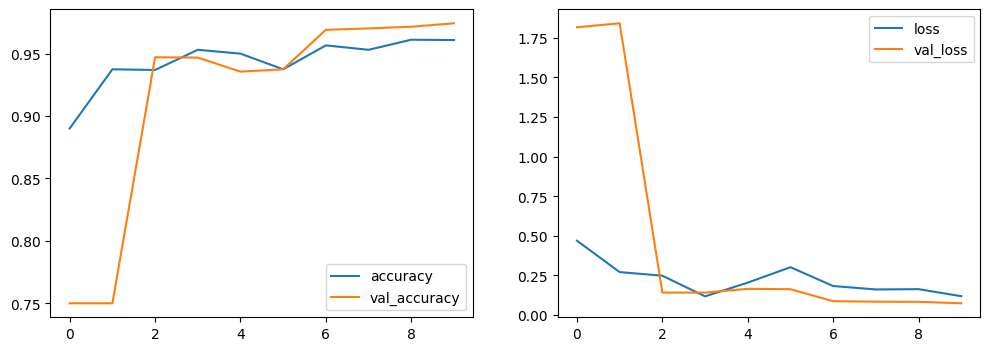

In [12]:
plt.figure(figsize=(12,4))
plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label = "accuracy")
plt.plot(history.history["val_accuracy"], label = "val_accuracy")
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label = "loss")
plt.plot(history.history["val_loss"], label = "val_loss")
plt.legend();

## Learning Curve Analysis

### Accuracy
Training accuracy (blue) rises steadily from ~0.88 to ~0.96 over ten epochs. Validation accuracy (orange) shows a two-epoch plateau at ~0.75 then jumps to ~0.94 at epoch 2 and continues climbing to ~0.97 by the final epoch.

Notably, validation accuracy consistently **meets or slightly exceeds** training accuracy from epoch 2 onward. This is a healthy sign: the augmentation applied only at training time acts as a regulariser, making the training objective harder than the clean validation set. The negligible train/val gap confirms the model is **not overfitting**.

### Loss
Training loss (blue) drops from ~0.48 to ~0.12 and remains low and stable. Validation loss (orange) starts very high (~1.8) due to the untrained network and the prefetch warm-up, then falls sharply to ~0.17 at epoch 2 and continues declining to ~0.07–0.10 — converging tightly with training loss. There is **no widening gap** between the two curves at any point, which would be the primary signal of overfitting.

### Overall Assessment
The model is well-calibrated for this binary task:
- Smooth, converging curves from epoch 2 indicate stable optimisation under Cosine Decay.
- The absence of a train/val divergence rules out significant overfitting; class weights and data augmentation are contributing effectively.
- Both curves are still trending slightly upward at epoch 9, suggesting the model has not fully plateaued and could benefit from additional epochs. The  callback with  ensures the best checkpoint is retained even if training continues past the optimum.

In [13]:
# load the saved weights into a model
cnn.load_weights("cnn.weights.h5")
history_loaded = pickle.load(open("cnn.pkl", "rb"))

In [14]:
cnn.evaluate(X_test, y_test)

250/250 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.9744 - loss: 0.0746 - precision: 0.9869


[0.07456395030021667, 0.9743750095367432, 0.9868929386138916]